# FigShare Sleep Data: Conversion & Data quality changes

This notebook handles converting the raw FigShare sleep dataset into PyEcog format

Raw format: **.dat** (sleep scores + power spectra + EEG/EMG variance + temperature) and **.eeg** (raw 200Hz EEG)

PyEcog format: separate .bin and .meta per modality (EEG, EMG, SleepScore, Temperature)

In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# project root to import pyecog modules
sys.path.insert(0, os.path.abspath('..'))
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [215]:
from pyecog2.convert_figshare_sleep_data import readbinary_dat, convert_animal_to_multimodal

1. Data

Each .dat file has 86,400 records (one per 4-second epoch, 96 hours total).
Each record: 1 byte sleep score + 401 float32 power spectrum + 3 float32 (EEG var, EMG var, temp).

In [216]:
sleep_scores, power_spectra, eeg_var, emg_var, temperature = readbinary_dat('data/M1EXP1.dat')
power_spectra.shape

Read data/M1EXP1.dat: 86400 epochs, temp recorded: False


(86400, 401)

In [217]:
sleep_scores[:20]

'wwwwwwwwwwwwwwwwwwww'

In [218]:
(temperature != 0).any()

False

2. Data Quality: Artifact-Marked Epochs

In the dataset sleep states are manually classified:
- 'w': Wake, 'n': NREM, 'r': REM
- '1': Wake (artifact), '2': NREM (artifact), '3': REM (artifact)

The 1 / 2 / 3 states are epochs where the signal is too noisy to fully trust but have still been scored as w / nrem / rem respectively.

In [219]:
states = np.array(list(sleep_scores))
clean_mask = np.isin(states, ['w', 'n', 'r'])
artifact_mask = np.isin(states, ['1', '2', '3'])

n_total = len(states)
n_artifact = np.sum(artifact_mask)
print(f'Total epochs: {n_total:,}')
print(f'Artifact marked: {n_artifact:,} ({n_artifact/n_total*100:.1f}%)')
print(f'Normal: {np.sum(clean_mask):,} ({np.sum(clean_mask)/n_total*100:.1f}%)')

Total epochs: 86,400
Artifact marked: 2,381 (2.8%)
Normal: 84,019 (97.2%)


In [220]:
# distribution of artifact marked sleep states
artifact_labels = {'1': 'Wake (artifact)', '2': 'NREM (artifact)', '3': 'REM (artifact)'}
artifact_chars = states[artifact_mask]
unique_chars, counts = np.unique(artifact_chars, return_counts=True)

for char, count in zip(unique_chars, counts):
    pct = count / n_artifact * 100
    print(f'{artifact_labels[char]}: {count} epochs ({pct:.1f}%)')

Wake (artifact): 2289 epochs (96.1%)
NREM (artifact): 58 epochs (2.4%)
REM (artifact): 34 epochs (1.4%)


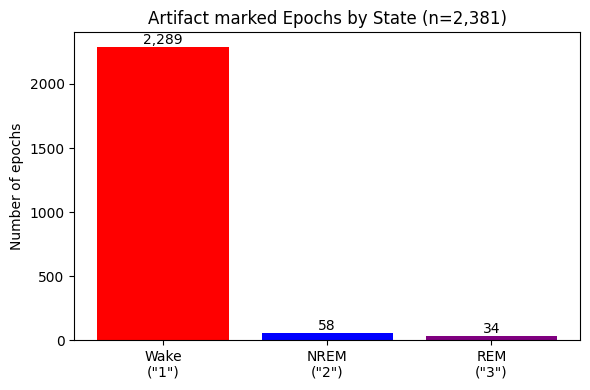

In [221]:
# distribution of artifact-marked sleep states
artifact_labels = {'1': 'Wake', '2': 'NREM', '3': 'REM'}
artifact_chars = states[artifact_mask]
unique_chars, counts = np.unique(artifact_chars, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'1': 'red', '2': 'blue', '3': 'purple'}
labels = [f'{artifact_labels[c]}\n("{c}")' for c in unique_chars]
bars = ax.bar(labels, counts, color=[colors[c] for c in unique_chars])
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('Number of epochs')
ax.set_title(f'Artifact marked Epochs by State (n={n_artifact:,})')
plt.tight_layout()
plt.show()

Since the artifact codes (1, 2, 3) are linked to the actual sleep state, i'm mapping them to the states.

**1 -> w**, **2 -> n**, **3 -> r**. The 'artifact' flag's relevant for EEG quality analysis but not for sleep state classification.

In [222]:
def map_artifact_to_state(sleep_scores):
    mapping = {'1': 'w', '2': 'n', '3': 'r'}
    return np.array([mapping.get(s, s) for s in sleep_scores])

In [223]:
mapped = map_artifact_to_state(list(sleep_scores))
n_remaining = np.sum(~np.isin(mapped, ['w', 'n', 'r']))
n_remaining

0

In [224]:
print('distribution before vs after mapping')
for state, name in [('w', 'Wake'), ('n', 'NREM'), ('r', 'REM')]:
    before = np.sum(states == state)
    after = np.sum(mapped == state)
    print(f'{name}: {before} -> {after}')

distribution before vs after mapping
Wake: 47407 -> 49696
NREM: 32310 -> 32368
REM: 4302 -> 4336


3. Checking across multiple files/animals

In [225]:
import glob

dat_files = sorted(glob.glob('data/*.dat'))
print(f'{len(dat_files)} .dat files\n')

summary_rows = []
for dat_file in dat_files:
    animal_id = os.path.splitext(os.path.basename(dat_file))[0]
    scores, _, _, _, temp = readbinary_dat(dat_file)
    states = np.array(list(scores))
    artifact = np.isin(states, ['1', '2', '3'])
    
    summary_rows.append({
        'animal': animal_id,
        'total': len(states),
        'artifact': np.sum(artifact),
        'artifact_percent': np.sum(artifact) / len(states) * 100,
        'has_temp': (temp != 0).any()
    })

summary = pd.DataFrame(summary_rows)
summary

Read data/M1EXP1.dat: 86400 epochs, temp recorded: False


4 .dat files



Read data/M1EXP2.dat: 86400 epochs, temp recorded: True
Read data/M2EXP1.dat: 86400 epochs, temp recorded: False
Read data/M3EXP1.dat: 86400 epochs, temp recorded: False


,animal,total,artifact,artifact_percent,has_temp
0,M1EXP1,86400,2381,2.755787,False
1,M1EXP2,86400,3875,4.484954,True
2,M2EXP1,86400,2761,3.195602,False
3,M3EXP1,86400,640,0.740741,False


4. Convert to PyEcog format

Using the conversion script to create separate `.bin` + `.meta` files per modality.

In [226]:
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

# convert all animals that have matching .dat + .eeg pairs
for dat_file in dat_files:
    animal_id = os.path.splitext(os.path.basename(dat_file))[0]
    eeg_file = dat_file.replace('.dat', '.eeg')
    output_folder = os.path.join('data', 'converted', animal_id)
    
    if not os.path.exists(eeg_file):
        print(f'{animal_id}: no .eeg file, skipping')
        continue
    
    created = convert_animal_to_multimodal(dat_file, eeg_file, output_folder, animal_id)
    print(f'Created: {list(created.keys())}')

Converting M1EXP1
Read data/M1EXP1.dat: 86400 epochs, temp recorded: False
Created metadata file: data/M1EXP1.meta (modality: voltage, sample frequency: 200 Hz)
Created metadata file: data/converted/M1EXP1/M1EXP1_EMG.meta (modality: variance, sample frequency: 0.25 Hz)
  M1EXP1: temperature not recorded, skipping
Created metadata file: data/converted/M1EXP1/M1EXP1_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 47407 epochs
NREM: 32310 epochs
REM: 4302 epochs
Converting M1EXP2
Read data/M1EXP2.dat: 86400 epochs, temp recorded: True
Created metadata file: data/M1EXP2.meta (modality: voltage, sample frequency: 200 Hz)
Created metadata file: data/converted/M1EXP2/M1EXP2_EMG.meta (modality: variance, sample frequency: 0.25 Hz)


Created: ['EEG', 'EMG', 'SleepScore']


Created metadata file: data/converted/M1EXP2/M1EXP2_Temperature.meta (modality: temperature, sample frequency: 0.25 Hz)
Created metadata file: data/converted/M1EXP2/M1EXP2_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 44881 epochs
NREM: 33124 epochs
REM: 4520 epochs
Converting M2EXP1
Read data/M2EXP1.dat: 86400 epochs, temp recorded: False
Created metadata file: data/M2EXP1.meta (modality: voltage, sample frequency: 200 Hz)
Created metadata file: data/converted/M2EXP1/M2EXP1_EMG.meta (modality: variance, sample frequency: 0.25 Hz)
  M2EXP1: temperature not recorded, skipping
Created metadata file: data/converted/M2EXP1/M2EXP1_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 47153 epochs
NREM: 32352 epochs
REM: 4134 epochs


Created: ['EEG', 'EMG', 'Temperature', 'SleepScore']
Created: ['EEG', 'EMG', 'SleepScore']
M3EXP1: no .eeg file, skipping


5. artifact mapping to converted SleepScore files

I realised when opening the SleepScore.meta file in PyEcog there was a large amount of '0' values on the graph.
This is because the conversion script only recognises 'w', 'n', 'r' as valid states. When it sees artifact characters '1', '2', '3' in the raw data, they don't match any mapping and default to 0 in the .bin file. 

This step maps them to their actual states (1->wake, 2->NREM, 3->REM) and overwrites the file(s).

In [227]:
score_char_to_num = {'w': 1, 'n': 2, 'r': 3}

for dat_file in dat_files:
    animal_id = os.path.splitext(os.path.basename(dat_file))[0]
    score_path = os.path.join('data', 'converted', animal_id, f'{animal_id}_SleepScore.bin')
    
    if not os.path.exists(score_path):
        print(f'{animal_id}: no SleepScore.bin found, skipping')
        continue
    
    # read raw scores from .dat, map artifacts to their states
    scores, _, _, _, _ = readbinary_dat(dat_file)
    mapped = map_artifact_to_state(list(scores))
    # convert mapped characters to numeric
    mapped_numeric = np.array([score_char_to_num.get(s, 0) for s in mapped], dtype=np.uint8)
    # compare with original bin
    original = np.fromfile(score_path, dtype=np.uint8)
    n_changed = np.sum(original != mapped_numeric)
    
    # overwrite with corrected data
    mapped_numeric.tofile(score_path)

Read data/M1EXP1.dat: 86400 epochs, temp recorded: False
Read data/M1EXP2.dat: 86400 epochs, temp recorded: True
Read data/M2EXP1.dat: 86400 epochs, temp recorded: False


M3EXP1: no SleepScore.bin found, skipping
